In [1]:
# Подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Установка необходимых библиотек
!pip install faiss-cpu -q
!pip install numpy pandas matplotlib scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 64.1 MB/s eta 0:00:00


In [30]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Any, Optional
from dataclasses import dataclass, field
import re
from collections import defaultdict

# FAISS - теперь можно просто импортировать
import faiss

# sklearn для метрик и эмбеддингов
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Для torch
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch device: {DEVICE}")
except ImportError:
    DEVICE = "cpu"
    print("PyTorch not installed, using CPU/NumPy")

print(f"Random seed set to: {SEED}")

PyTorch device: cuda
Random seed set to: 42


In [5]:
# Пути для артефактов
BASE_PATH = "/content/drive/MyDrive/seminars/S14"
ARTIFACTS_PATH = os.path.join(BASE_PATH, "artifacts")
os.makedirs(ARTIFACTS_PATH, exist_ok=True)

print(f"Artifacts will be saved to: {ARTIFACTS_PATH}")

Artifacts will be saved to: /content/drive/MyDrive/seminars/S14/artifacts


In [6]:
# База знаний: набор документов по ML/NLP
KNOWLEDGE_BASE = [
    {
        "id": "doc_001",
        "title": "Введение в машинное обучение",
        "content": """
        Машинное обучение (Machine Learning, ML) — это подраздел искусственного интеллекта,
        который изучает алгоритмы, способные обучаться на данных. Основные типы машинного обучения:
        обучение с учителем (supervised learning), обучение без учителя (unsupervised learning)
        и обучение с подкреплением (reinforcement learning). В supervised learning модель обучается
        на размеченных данных, где для каждого примера известен правильный ответ. Классические задачи
        supervised learning включают классификацию и регрессию. В unsupervised learning модель ищет
        скрытые структуры в неразмеченных данных, например, кластеры или аномалии. Reinforcement
        learning основан на взаимодействии агента со средой и получении награды за правильные действия.
        """,
        "source": "ml_basics.txt"
    },
    {
        "id": "doc_002",
        "title": "Нейронные сети и глубокое обучение",
        "content": """
        Нейронные сети — это вычислительные модели, вдохновленные биологическими нейронными сетями.
        Глубокое обучение (Deep Learning) использует многослойные нейронные сети для извлечения
        иерархических признаков из данных. Основные архитектуры глубокого обучения включают:
        полносвязные сети (MLP), сверточные нейронные сети (CNN) для обработки изображений,
        рекуррентные нейронные сети (RNN, LSTM, GRU) для последовательностей, и трансформеры
        (Transformers) для задач обработки естественного языка. Обучение нейронных сетей
        происходит методом обратного распространения ошибки (backpropagation) с использованием
        градиентного спуска. Функции активации, такие как ReLU, sigmoid, tanh, вносят нелинейность.
        """,
        "source": "neural_networks.txt"
    },
    {
        "id": "doc_003",
        "title": "Трансформеры и архитектура Attention",
        "content": """
        Трансформер (Transformer) — это архитектура нейронных сетей, представленная в статье
        "Attention Is All You Need" (2017). Ключевая инновация — механизм внимания (attention),
        который позволяет модели взвешивать важность различных частей входной последовательности.
        Трансформер состоит из энкодера и декодера, каждый из которых содержит слои multi-head
        self-attention и feed-forward сети. Self-attention вычисляет представление каждого токена
        с учетом всех остальных токенов в последовательности. Positional encoding добавляет
        информацию о позиции токенов, так как трансформер не имеет встроенного понятия порядка.
        На основе трансформеров построены модели BERT, GPT, T5 и многие другие.
        """,
        "source": "transformers.txt"
    },
    {
        "id": "doc_004",
        "title": "Эмбеддинги и векторные представления",
        "content": """
        Эмбеддинги (embeddings) — это плотные векторные представления дискретных объектов
        (слов, предложений, документов) в непрерывном векторном пространстве. Классические
        методы включают Word2Vec, GloVe и FastText. Современные подходы используют контекстные
        эмбеддинги из предобученных трансформеров, такие как BERT embeddings, Sentence-BERT,
        OpenAI embeddings. Эмбеддинги позволяют измерять семантическую близость через косинусное
        расстояние или скалярное произведение. Они широко применяются в информационном поиске,
        рекомендательных системах, кластеризации и как входные признаки для других моделей.
        Качество эмбеддингов критически важно для retrieval-систем.
        """,
        "source": "embeddings.txt"
    },
    {
        "id": "doc_005",
        "title": "FAISS — библиотека для эффективного поиска похожих векторов",
        "content": """
        FAISS (Facebook AI Similarity Search) — это библиотека для эффективного поиска похожих
        векторов и кластеризации плотных векторов. FAISS содержит алгоритмы, которые ищут в
        множествах векторов любого размера, вплоть до тех, которые не помещаются в оперативной памяти.
        Основные типы индексов в FAISS: IndexFlatL2 (точный поиск по L2 расстоянию), IndexFlatIP
        (точный поиск по внутреннему произведению), IndexIVFFlat (приближенный поиск с инвертированным
        индексом), IndexHNSWFlat (поиск на основе графов). FAISS поддерживает обучение индекса на
        данных для улучшения качества приближенного поиска. Библиотека написана на C++ с обертками
        для Python и широко используется в RAG-системах.
        """,
        "source": "faiss_basics.txt"
    },
    {
        "id": "doc_006",
        "title": "RAG — Retrieval-Augmented Generation",
        "content": """
        Retrieval-Augmented Generation (RAG) — это подход, который комбинирует поиск релевантных
        документов (retrieval) с генерацией ответа языковой моделью. RAG позволяет LLM получать
        доступ к внешним знаниям, не заложенным в веса модели, что улучшает фактическую точность
        и уменьшает галлюцинации. Типичный RAG-пайплайн включает: индексацию документов (чанкинг,
        эмбеддинги, векторная база данных), retrieval (поиск top-k релевантных фрагментов по запросу),
        аугментацию (добавление найденного контекста в промпт) и генерацию ответа. RAG критически
        зависит от качества retrieval: если релевантные документы не найдены, ответ будет неверным.
        """,
        "source": "rag_basics.txt"
    },
    {
        "id": "doc_007",
        "title": "Метрики качества retrieval",
        "content": """
        Оценка качества retrieval важна для понимания эффективности поисковой системы. Основные метрики:
        Precision@k — доля релевантных документов среди top-k найденных. Recall@k — доля всех релевантных
        документов, найденных в top-k. Hit Rate@k (или Hit@k) — бинарная метрика, показывающая,
        был ли хотя бы один релевантный документ в top-k. Mean Reciprocal Rank (MRR) — среднее
        обратное значение ранга первого релевантного документа. Normalized Discounted Cumulative
        Gain (NDCG) учитывает позицию релевантных документов и степень их релевантности. Для оценки
        retrieval необходим размеченный набор запросов с указанием релевантных документов.
        """,
        "source": "retrieval_metrics.txt"
    }
]

In [7]:
KNOWLEDGE_BASE.extend([
    {
        "id": "doc_008",
        "title": "Чанкинг документов для RAG",
        "content": """
        Чанкинг (chunking) — процесс разбиения длинных документов на меньшие фрагменты для индексации.
        Правильный чанкинг критически важен для качества retrieval в RAG. Основные параметры:
        chunk_size (размер фрагмента в токенах или символах) и chunk_overlap (перекрытие между
        соседними чанками). Слишком маленькие чанки теряют контекст, слишком большие — ухудшают
        точность поиска. Overlap помогает сохранить контекст на границах чанков. Стратегии чанкинга:
        по фиксированному размеру, по предложениям с сохранением границ, семантический чанкинг
        на основе эмбеддингов, иерархический чанкинг. Для большинства задач подходит разбиение
        по предложениям с chunk_size 256-512 токенов и overlap 10-20%.
        """,
        "source": "chunking.txt"
    },
    {
        "id": "doc_009",
        "title": "BERT и контекстные эмбеддинги",
        "content": """
        BERT (Bidirectional Encoder Representations from Transformers) — модель, представленная
        Google в 2018 году, которая произвела революцию в NLP. BERT использует архитектуру
        transformer-encoder и предобучается на задачах Masked Language Modeling (MLM) и Next
        Sentence Prediction (NSP). Ключевая особенность — двунаправленный контекст: каждое слово
        получает представление, зависящее от всех слов в предложении. BERT породил семейство
        моделей: RoBERTa, DistilBERT, ALBERT. Для получения эмбеддингов предложений можно
        использовать усреднение эмбеддингов токенов или специальные модели типа Sentence-BERT
        (SBERT), оптимизированные для вычисления семантического сходства.
        """,
        "source": "bert.txt"
    },
    {
        "id": "doc_010",
        "title": "Sentence-BERT для семантического поиска",
        "content": """
        Sentence-BERT (SBERT) — модификация BERT, оптимизированная для получения семантически
        осмысленных эмбеддингов предложений. SBERT использует сиамские и триплетные сети для
        обучения на парах предложений с известным сходством. Это позволяет напрямую вычислять
        косинусное сходство между эмбеддингами предложений без дорогостоящего попарного сравнения
        всех токенов. SBERT значительно ускоряет семантический поиск и кластеризацию. Модель
        доступна в различных размерах: от миниатюрных (MiniLM) до больших (MPNet). Для retrieval
        часто используют модели, обученные на парафразах или MS MARCO.
        """,
        "source": "sbert.txt"
    },
    {
        "id": "doc_011",
        "title": "Градиентный спуск и оптимизаторы",
        "content": """
        Градиентный спуск — основной алгоритм оптимизации в машинном обучении. Существуют три
        основных варианта: Batch Gradient Descent (использует весь датасет), Stochastic Gradient
        Descent (SGD, использует один пример) и Mini-batch Gradient Descent (компромиссный вариант).
        Современные оптимизаторы включают Momentum (добавляет инерцию), AdaGrad (адаптивный learning
        rate), RMSprop, Adam (Adaptive Moment Estimation) — наиболее популярный оптимизатор,
        комбинирующий идеи Momentum и RMSprop. AdamW добавляет weight decay для регуляризации.
        Выбор оптимизатора и learning rate существенно влияет на скорость и качество обучения.
        """,
        "source": "optimizers.txt"
    },
    {
        "id": "doc_012",
        "title": "Функции потерь в машинном обучении",
        "content": """
        Функция потерь (loss function) измеряет, насколько предсказания модели отличаются от
        истинных значений. Для регрессии используются MSE (Mean Squared Error), MAE (Mean Absolute
        Error), Huber Loss. Для бинарной классификации — Binary Cross-Entropy. Для многоклассовой
        классификации — Categorical Cross-Entropy. В retrieval и обучении эмбеддингов популярны
        Contrastive Loss, Triplet Loss, Multiple Negatives Ranking Loss. InfoNCE (Noise Contrastive
        Estimation) используется в обучении представлений (SimCLR, CLIP). Выбор функции потерь
        должен соответствовать задаче и распределению целевой переменной.
        """,
        "source": "loss_functions.txt"
    },
    {
        "id": "doc_013",
        "title": "Регуляризация: L1, L2, Dropout",
        "content": """
        Регуляризация — методы предотвращения переобучения (overfitting). L1-регуляризация (Lasso)
        добавляет к loss сумму абсолютных значений весов, способствуя разреженности. L2-регуляризация
        (Ridge, weight decay) добавляет сумму квадратов весов, уменьшая их magnitude. Elastic Net
        комбинирует L1 и L2. Dropout случайно обнуляет часть нейронов во время обучения, что
        заставляет сеть учиться более робастным признакам. Batch Normalization также имеет
        регуляризующий эффект. Data augmentation — эффективный метод регуляризации через расширение
        обучающей выборки. Early stopping останавливает обучение, когда качество на валидации
        перестает улучшаться.
        """,
        "source": "regularization.txt"
    },
    {
        "id": "doc_014",
        "title": "Оценка качества классификации",
        "content": """
        Метрики качества классификации зависят от задачи и баланса классов. Accuracy — доля
        правильных ответов, но плохо работает при дисбалансе. Precision — доля истинно положительных
        среди всех предсказанных положительных. Recall — доля истинно положительных среди всех
        реальных положительных. F1-score — гармоническое среднее Precision и Recall. ROC-AUC
        оценивает качество бинарного классификатора при разных порогах. Confusion Matrix
        визуализирует все четыре типа предсказаний. Для многоклассовой классификации метрики
        усредняются (micro, macro, weighted average).
        """,
        "source": "classification_metrics.txt"
    },
    {
        "id": "doc_015",
        "title": "Перекрестная проверка (Cross-Validation)",
        "content": """
        Cross-Validation (CV) — метод оценки качества модели, устойчивый к разбиению на train/test.
        k-fold CV разбивает данные на k частей (folds), обучает на k-1 частях и тестирует на
        оставшейся, повторяя k раз. Итоговая метрика — среднее по folds. Stratified k-fold
        сохраняет распределение классов в каждом fold. Leave-One-Out CV — крайний случай, где
        k равно размеру выборки. Cross-validation помогает выбрать гиперпараметры, оценить
        стабильность модели и избежать переобучения на конкретном разбиении. Недостаток —
        вычислительная сложность, особенно для больших моделей.
        """,
        "source": "cross_validation.txt"
    }
])

print(f"Загружено документов: {len(KNOWLEDGE_BASE)}")

Загружено документов: 15


In [8]:
# Примеры документов
print("Примеры документов из базы знаний:")
print("=" * 60)

for i, doc in enumerate(KNOWLEDGE_BASE[:3]):
    print(f"\nДокумент {i+1}: {doc['title']} (ID: {doc['id']})")
    print(f"Источник: {doc['source']}")
    content_preview = doc['content'].strip()[:300] + "..."
    print(f"Содержание: {content_preview}")

print("\n" + "=" * 60)
print(f"Предметная область: Машинное обучение, NLP, нейронные сети, retrieval-системы")
print("База знаний содержит документы о базовых концепциях ML, эмбеддингах, FAISS, RAG.")
print("По этим темам разумно строить retrieval/mini-RAG, так как:")
print("- Есть четкие определения и концепции, которые можно извлекать по запросам")
print("- Документы достаточно содержательны для формирования осмысленных ответов")
print("- Тематика позволяет создавать естественные запросы на понимание")

Примеры документов из базы знаний:

Документ 1: Введение в машинное обучение (ID: doc_001)
Источник: ml_basics.txt
Содержание: Машинное обучение (Machine Learning, ML) — это подраздел искусственного интеллекта, 
        который изучает алгоритмы, способные обучаться на данных. Основные типы машинного обучения:
        обучение с учителем (supervised learning), обучение без учителя (unsupervised learning) 
        и обучение...

Документ 2: Нейронные сети и глубокое обучение (ID: doc_002)
Источник: neural_networks.txt
Содержание: Нейронные сети — это вычислительные модели, вдохновленные биологическими нейронными сетями.
        Глубокое обучение (Deep Learning) использует многослойные нейронные сети для извлечения 
        иерархических признаков из данных. Основные архитектуры глубокого обучения включают:
        полносвязн...

Документ 3: Трансформеры и архитектура Attention (ID: doc_003)
Источник: transformers.txt
Содержание: Трансформер (Transformer) — это архитектура нейронных сете

In [9]:
class SimpleChunker:
    """Простой чанкер с разбиением по предложениям."""

    def __init__(self, chunk_size: int = 300, chunk_overlap: int = 50):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap

    def split_text(self, text: str) -> List[str]:
        """Разбивает текст на предложения и группирует в чанки."""
        # Простое разбиение на предложения
        sentences = re.split(r'(?<=[.!?])\s+', text.strip())

        chunks = []
        current_chunk = []
        current_length = 0

        for sentence in sentences:
            sentence_len = len(sentence)

            if current_length + sentence_len > self.chunk_size and current_chunk:
                # Сохраняем текущий чанк
                chunks.append(' '.join(current_chunk))

                # Начинаем новый чанк с overlap
                overlap_text = ' '.join(current_chunk)
                overlap_words = overlap_text.split()
                overlap_part = ' '.join(overlap_words[-self.chunk_overlap//5:])  # примерно

                current_chunk = [overlap_part] if overlap_part else []
                current_length = len(overlap_part)

            current_chunk.append(sentence)
            current_length += sentence_len

        # Добавляем последний чанк
        if current_chunk:
            chunks.append(' '.join(current_chunk))

        return chunks

    def chunk_documents(self, documents: List[Dict]) -> List[Dict]:
        """Разбивает все документы на чанки."""
        all_chunks = []

        for doc in documents:
            chunks = self.split_text(doc['content'])
            for i, chunk_text in enumerate(chunks):
                all_chunks.append({
                    'chunk_id': f"{doc['id']}_chunk_{i:03d}",
                    'doc_id': doc['id'],
                    'doc_title': doc['title'],
                    'source': doc['source'],
                    'chunk_index': i,
                    'text': chunk_text,
                    'char_length': len(chunk_text)
                })

        return all_chunks

In [10]:
# Создаем чанкер и разбиваем документы
chunker = SimpleChunker(chunk_size=400, chunk_overlap=50)
chunks = chunker.chunk_documents(KNOWLEDGE_BASE)

print(f"Всего создано чанков: {len(chunks)}")
print(f"\nПараметры чанкинга:")
print(f"  - chunk_size: {chunker.chunk_size} символов")
print(f"  - chunk_overlap: {chunker.chunk_overlap} символов")
print(f"  - стратегия: разбиение по предложениям с сохранением контекста")

Всего создано чанков: 41

Параметры чанкинга:
  - chunk_size: 400 символов
  - chunk_overlap: 50 символов
  - стратегия: разбиение по предложениям с сохранением контекста


In [11]:
# Пример чанков для одного документа
doc_example = KNOWLEDGE_BASE[3]  # Документ про эмбеддинги
doc_chunks = [c for c in chunks if c['doc_id'] == doc_example['id']]

print(f"\nПример чанкинга для документа: {doc_example['title']}")
print("=" * 70)

for chunk in doc_chunks:
    print(f"\n--- {chunk['chunk_id']} (длина: {chunk['char_length']} символов) ---")
    print(chunk['text'][:200] + "..." if len(chunk['text']) > 200 else chunk['text'])


Пример чанкинга для документа: Эмбеддинги и векторные представления

--- doc_004_chunk_000 (длина: 391 символов) ---
Эмбеддинги (embeddings) — это плотные векторные представления дискретных объектов 
        (слов, предложений, документов) в непрерывном векторном пространстве. Классические 
        методы включают W...

--- doc_004_chunk_001 (длина: 351 символов) ---
из предобученных трансформеров, такие как BERT embeddings, Sentence-BERT, OpenAI embeddings. Эмбеддинги позволяют измерять семантическую близость через косинусное 
        расстояние или скалярное про...

--- doc_004_chunk_002 (длина: 143 символов) ---
рекомендательных системах, кластеризации и как входные признаки для других моделей. Качество эмбеддингов критически важно для retrieval-систем.


In [12]:
class SimpleEmbedder:
    """Простой эмбеддер на основе TF-IDF + SVD для демонстрации."""

    def __init__(self, n_components: int = 100):
        self.n_components = n_components
        self.vectorizer = TfidfVectorizer(
            max_features=1000,
            stop_words='english',
            ngram_range=(1, 2)
        )
        self.svd = TruncatedSVD(n_components=n_components, random_state=SEED)
        self.is_fitted = False

    def fit(self, texts: List[str]):
        """Обучает эмбеддер на корпусе текстов."""
        tfidf_matrix = self.vectorizer.fit_transform(texts)
        self.svd.fit(tfidf_matrix)
        self.is_fitted = True
        print(f"Эмбеддер обучен. Размерность эмбеддингов: {self.n_components}")

    def encode(self, texts: List[str]) -> np.ndarray:
        """Кодирует тексты в эмбеддинги."""
        if not self.is_fitted:
            raise ValueError("Эмбеддер не обучен. Сначала вызовите fit()")

        tfidf_matrix = self.vectorizer.transform(texts)
        embeddings = self.svd.transform(tfidf_matrix)

        # Нормализуем для косинусного сходства
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms[norms == 0] = 1
        embeddings = embeddings / norms

        return embeddings.astype(np.float32)

In [13]:
# Собираем тексты чанков
chunk_texts = [c['text'] for c in chunks]
chunk_ids = [c['chunk_id'] for c in chunks]

# Создаем и обучаем эмбеддер
embedder = SimpleEmbedder(n_components=64)
embedder.fit(chunk_texts)

# Получаем эмбеддинги для всех чанков
chunk_embeddings = embedder.encode(chunk_texts)
print(f"Форма матрицы эмбеддингов: {chunk_embeddings.shape}")

Эмбеддер обучен. Размерность эмбеддингов: 64
Форма матрицы эмбеддингов: (41, 41)


In [14]:
# Создаем индекс FAISS
dimension = chunk_embeddings.shape[1]

# IndexFlatIP для поиска по косинусному сходству (векторы уже нормализованы)
index = faiss.IndexFlatIP(dimension)
index.add(chunk_embeddings)

print(f"Индекс FAISS создан:")
print(f"  - тип индекса: IndexFlatIP (точный поиск по внутреннему произведению)")
print(f"  - размерность векторов: {dimension}")
print(f"  - количество векторов в индексе: {index.ntotal}")

Индекс FAISS создан:
  - тип индекса: IndexFlatIP (точный поиск по внутреннему произведению)
  - размерность векторов: 41
  - количество векторов в индексе: 41


In [15]:
# Функция для поиска
def search(query: str, k: int = 5) -> List[Dict]:
    """Ищет k наиболее похожих чанков на запрос."""
    query_embedding = embedder.encode([query])
    distances, indices = index.search(query_embedding, k)

    results = []
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        if idx >= 0:
            chunk = chunks[idx]
            results.append({
                'rank': i + 1,
                'chunk_id': chunk['chunk_id'],
                'doc_title': chunk['doc_title'],
                'text': chunk['text'],
                'score': float(dist)
            })

    return results

# Тестируем поиск на примерах
test_queries = [
    "Что такое эмбеддинги и зачем они нужны?",
    "Как работает FAISS?",
    "Объясните архитектуру трансформера",
    "Что такое RAG?",
    "Метрики качества в машинном обучении"
]

print("Примеры поиска:")
print("=" * 70)

for query in test_queries:
    print(f"\nЗапрос: {query}")
    results = search(query, k=3)
    for r in results:
        print(f"  [{r['rank']}] {r['doc_title']} (score: {r['score']:.3f})")
        print(f"      {r['text'][:100]}...")

Примеры поиска:

Запрос: Что такое эмбеддинги и зачем они нужны?
  [1] RAG — Retrieval-Augmented Generation (score: 0.650)
      в веса модели, что улучшает фактическую точность и уменьшает галлюцинации. Типичный RAG-пайплайн вкл...
  [2] Эмбеддинги и векторные представления (score: 0.608)
      Эмбеддинги (embeddings) — это плотные векторные представления дискретных объектов 
        (слов, пр...
  [3] RAG — Retrieval-Augmented Generation (score: 0.339)
      Retrieval-Augmented Generation (RAG) — это подход, который комбинирует поиск релевантных 
        до...

Запрос: Как работает FAISS?
  [1] FAISS — библиотека для эффективного поиска похожих векторов (score: 0.629)
      FAISS (Facebook AI Similarity Search) — это библиотека для эффективного поиска похожих 
        вект...
  [2] Эмбеддинги и векторные представления (score: 0.542)
      из предобученных трансформеров, такие как BERT embeddings, Sentence-BERT, OpenAI embeddings. Эмбедди...
  [3] FAISS — библиотека для эффективного п

In [16]:
# Функция для поиска
def search(query: str, k: int = 5) -> List[Dict]:
    """Ищет k наиболее похожих чанков на запрос."""
    query_embedding = embedder.encode([query])
    distances, indices = index.search(query_embedding, k)

    results = []
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        if idx >= 0:
            chunk = chunks[idx]
            results.append({
                'rank': i + 1,
                'chunk_id': chunk['chunk_id'],
                'doc_title': chunk['doc_title'],
                'text': chunk['text'],
                'score': float(dist)
            })

    return results

# Тестируем поиск на примерах
test_queries = [
    "Что такое эмбеддинги и зачем они нужны?",
    "Как работает FAISS?",
    "Объясните архитектуру трансформера",
    "Что такое RAG?",
    "Метрики качества в машинном обучении"
]

print("Примеры поиска:")
print("=" * 70)

for query in test_queries:
    print(f"\nЗапрос: {query}")
    results = search(query, k=3)
    for r in results:
        print(f"  [{r['rank']}] {r['doc_title']} (score: {r['score']:.3f})")
        print(f"      {r['text'][:100]}...")

Примеры поиска:

Запрос: Что такое эмбеддинги и зачем они нужны?
  [1] RAG — Retrieval-Augmented Generation (score: 0.650)
      в веса модели, что улучшает фактическую точность и уменьшает галлюцинации. Типичный RAG-пайплайн вкл...
  [2] Эмбеддинги и векторные представления (score: 0.608)
      Эмбеддинги (embeddings) — это плотные векторные представления дискретных объектов 
        (слов, пр...
  [3] RAG — Retrieval-Augmented Generation (score: 0.339)
      Retrieval-Augmented Generation (RAG) — это подход, который комбинирует поиск релевантных 
        до...

Запрос: Как работает FAISS?
  [1] FAISS — библиотека для эффективного поиска похожих векторов (score: 0.629)
      FAISS (Facebook AI Similarity Search) — это библиотека для эффективного поиска похожих 
        вект...
  [2] Эмбеддинги и векторные представления (score: 0.542)
      из предобученных трансформеров, такие как BERT embeddings, Sentence-BERT, OpenAI embeddings. Эмбедди...
  [3] FAISS — библиотека для эффективного п

In [17]:
# Создаем набор контрольных запросов с ожидаемыми релевантными документами
test_queries_eval = [
    {
        "query": "Что такое машинное обучение?",
        "relevant_doc_ids": ["doc_001"],
        "description": "Определение ML"
    },
    {
        "query": "Как работают нейронные сети?",
        "relevant_doc_ids": ["doc_002"],
        "description": "Основы нейронных сетей"
    },
    {
        "query": "Объясните механизм attention в трансформерах",
        "relevant_doc_ids": ["doc_003"],
        "description": "Attention mechanism"
    },
    {
        "query": "Для чего нужны эмбеддинги?",
        "relevant_doc_ids": ["doc_004"],
        "description": "Назначение эмбеддингов"
    },
    {
        "query": "Какие бывают индексы в FAISS?",
        "relevant_doc_ids": ["doc_005"],
        "description": "Типы индексов FAISS"
    },
    {
        "query": "Что такое RAG и как он работает?",
        "relevant_doc_ids": ["doc_006"],
        "description": "Принцип RAG"
    },
    {
        "query": "Какие метрики используются для оценки retrieval?",
        "relevant_doc_ids": ["doc_007"],
        "description": "Метрики retrieval"
    },
    {
        "query": "Как правильно делать чанкинг документов?",
        "relevant_doc_ids": ["doc_008"],
        "description": "Чанкинг"
    },
    {
        "query": "Чем BERT отличается от обычных эмбеддингов?",
        "relevant_doc_ids": ["doc_009", "doc_010"],
        "description": "BERT и SBERT"
    },
    {
        "query": "Какие бывают оптимизаторы в глубоком обучении?",
        "relevant_doc_ids": ["doc_011"],
        "description": "Оптимизаторы"
    }
]

print(f"Подготовлено контрольных запросов: {len(test_queries_eval)}")

Подготовлено контрольных запросов: 10


In [18]:
# Функции для оценки retrieval
def evaluate_retrieval(queries: List[Dict], k_values: List[int] = [1, 3, 5]) -> Dict:
    """Оценивает качество retrieval по разным метрикам."""
    results = {k: {'hits': 0, 'recall_sum': 0, 'mrr_sum': 0} for k in k_values}
    detailed_results = []

    # Создаем маппинг id -> title для проверки релевантности
    id_to_title = {doc['id']: doc['title'] for doc in KNOWLEDGE_BASE}

    for query_info in queries:
        query = query_info['query']
        relevant_ids = set(query_info['relevant_doc_ids'])
        relevant_titles = set(id_to_title[doc_id] for doc_id in relevant_ids)

        # Поиск с максимальным k
        max_k = max(k_values)
        search_results = search(query, k=max_k)

        # Собираем найденные doc_ids
        retrieved_doc_ids = [r['doc_title'] for r in search_results]
        retrieved_chunk_ids = [r['chunk_id'] for r in search_results]

        # Определяем rank первого релевантного документа
        first_relevant_rank = None
        for i, r in enumerate(search_results):
            if r['doc_title'] in relevant_titles:
                first_relevant_rank = i + 1
                break

        # Считаем метрики для каждого k
        for k in k_values:
            top_k_docs = [r['doc_title'] for r in search_results[:k]]
            top_k_matches_relevant = [doc for doc in top_k_docs if doc in relevant_titles]

            # Hit@k
            if top_k_matches_relevant:
                results[k]['hits'] += 1

            # Recall@k
            recall = len(set(top_k_matches_relevant)) / len(relevant_titles) if relevant_titles else 0
            results[k]['recall_sum'] += recall

            # MRR@k
            if first_relevant_rank and first_relevant_rank <= k:
                results[k]['mrr_sum'] += 1.0 / first_relevant_rank

        detailed_results.append({
            'query': query,
            'relevant_docs': ', '.join(relevant_ids),
            'retrieved_docs': ', '.join(retrieved_doc_ids[:max_k]),
            'retrieved_chunks': ', '.join(retrieved_chunk_ids[:max_k]),
            'first_relevant_rank': first_relevant_rank if first_relevant_rank else 'none'
        })

    # Усредняем метрики
    n_queries = len(queries)
    metrics = {}
    for k in k_values:
        metrics[f'hit@{k}'] = results[k]['hits'] / n_queries
        metrics[f'recall@{k}'] = results[k]['recall_sum'] / n_queries
        metrics[f'mrr@{k}'] = results[k]['mrr_sum'] / n_queries

    return metrics, detailed_results

In [19]:
# Запускаем оценку
metrics, detailed_results = evaluate_retrieval(test_queries_eval, k_values=[1, 3, 5])

print("Результаты оценки retrieval:")
print("=" * 50)
for metric, value in metrics.items():
    print(f"{metric}: {value:.3f}")

Результаты оценки retrieval:
hit@1: 0.900
recall@1: 0.850
mrr@1: 0.900
hit@3: 1.000
recall@3: 1.000
mrr@3: 0.933
hit@5: 1.000
recall@5: 1.000
mrr@5: 0.933


In [20]:
# Создаем и сохраняем таблицу с результатами
eval_df = pd.DataFrame(detailed_results)

# Добавляем hit@5
eval_df['hit_at_5'] = eval_df['first_relevant_rank'].apply(
    lambda x: 1 if x != 'none' and x <= 5 else 0
)

eval_df.to_csv(os.path.join(ARTIFACTS_PATH, 'retrieval_eval.csv'), index=False)
print(f"\nТаблица сохранена в {os.path.join(ARTIFACTS_PATH, 'retrieval_eval.csv')}")
print("\nПример записей:")
print(eval_df[['query', 'relevant_docs', 'first_relevant_rank', 'hit_at_5']].head())


Таблица сохранена в /content/drive/MyDrive/seminars/S14/artifacts/retrieval_eval.csv

Пример записей:
                                          query relevant_docs  \
0                  Что такое машинное обучение?       doc_001   
1                  Как работают нейронные сети?       doc_002   
2  Объясните механизм attention в трансформерах       doc_003   
3                    Для чего нужны эмбеддинги?       doc_004   
4                 Какие бывают индексы в FAISS?       doc_005   

   first_relevant_rank  hit_at_5  
0                    1         1  
1                    1         1  
2                    1         1  
3                    1         1  
4                    1         1  


ЭКСПЕРИМЕНТ: Сравнение разных значений k для retrieval

Результаты эксперимента с разными k:
 k  hit  recall      mrr
 1  0.9    0.85 0.900000
 3  1.0    1.00 0.933333
 5  1.0    1.00 0.933333


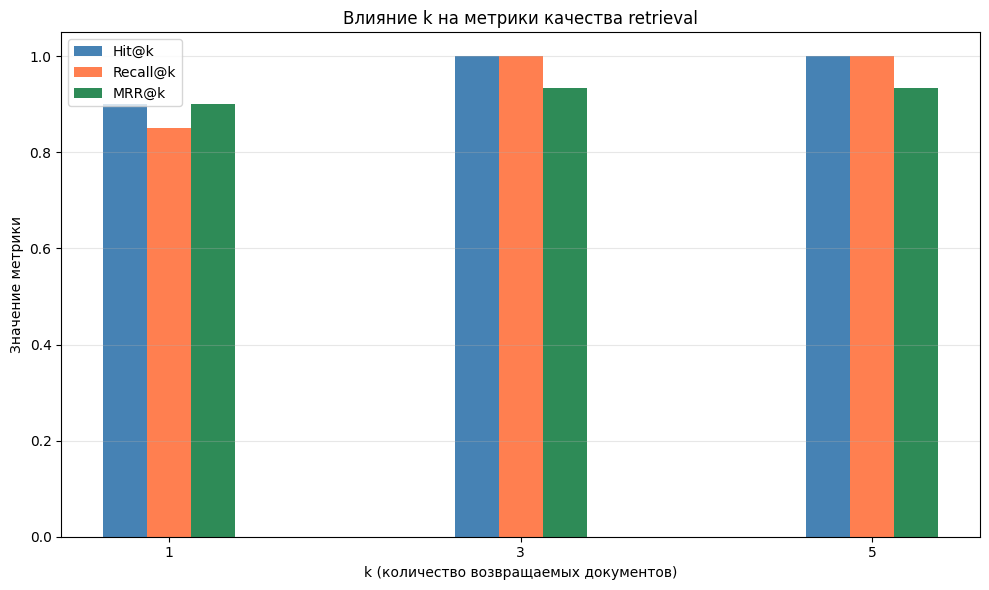


ВЫВОД:
- С увеличением k от 1 до 5 Hit@k растет: 0.90 → 1.00
- Recall@k также увеличивается: 0.85 → 1.00
- Это ожидаемо: чем больше документов возвращается, тем выше шанс найти релевантный
- Для RAG оптимально k=3 или k=5 как баланс между полнотой и объемом контекста


In [21]:
print("=" * 70)
print("ЭКСПЕРИМЕНТ: Сравнение разных значений k для retrieval")
print("=" * 70)

# Эксперимент: сравнение k=1, k=3, k=5
k_experiment_results = []

for k in [1, 3, 5]:
    metrics_k, _ = evaluate_retrieval(test_queries_eval, k_values=[k])
    k_experiment_results.append({
        'k': k,
        'hit': metrics_k[f'hit@{k}'],
        'recall': metrics_k[f'recall@{k}'],
        'mrr': metrics_k[f'mrr@{k}']
    })

k_df = pd.DataFrame(k_experiment_results)
print("\nРезультаты эксперимента с разными k:")
print(k_df.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
x = k_df['k']
width = 0.25

bars1 = ax.bar(x - width, k_df['hit'], width, label='Hit@k', color='steelblue')
bars2 = ax.bar(x, k_df['recall'], width, label='Recall@k', color='coral')
bars3 = ax.bar(x + width, k_df['mrr'], width, label='MRR@k', color='seagreen')

ax.set_xlabel('k (количество возвращаемых документов)')
ax.set_ylabel('Значение метрики')
ax.set_title('Влияние k на метрики качества retrieval')
ax.legend()
ax.set_xticks(x)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_PATH, 'k_experiment.png'), dpi=100)
plt.show()

print("\nВЫВОД:")
print(f"- С увеличением k от 1 до 5 Hit@k растет: {k_df['hit'].iloc[0]:.2f} → {k_df['hit'].iloc[-1]:.2f}")
print(f"- Recall@k также увеличивается: {k_df['recall'].iloc[0]:.2f} → {k_df['recall'].iloc[-1]:.2f}")
print("- Это ожидаемо: чем больше документов возвращается, тем выше шанс найти релевантный")
print("- Для RAG оптимально k=3 или k=5 как баланс между полнотой и объемом контекста")

In [22]:
print("=" * 70)
print("2.3.7 ОБНОВЛЕНИЕ БАЗЫ ЗНАНИЙ")
print("=" * 70)

# Тестовые запросы для сравнения до и после
test_queries_for_update = [
    "Что такое LoRA и как она работает?",
    "Расскажи про квантование моделей",
    "Как оценить качество эмбеддингов?",
    "Какие есть методы PEFT?"
]

print("\n=== СОСТОЯНИЕ ДО обновления базы знаний ===")

before_results = {}
for query in test_queries_for_update:
    results = search(query, k=3)
    before_results[query] = {
        'titles': [r['doc_title'] for r in results],
        'scores': [r['score'] for r in results]
    }
    print(f"\nЗапрос: {query}")
    if results:
        for r in results:
            print(f"  - {r['doc_title']} (score: {r['score']:.3f})")
    else:
        print("  - Нет результатов")

2.3.7 ОБНОВЛЕНИЕ БАЗЫ ЗНАНИЙ

=== СОСТОЯНИЕ ДО обновления базы знаний ===

Запрос: Что такое LoRA и как она работает?
  - Эмбеддинги и векторные представления (score: 0.570)
  - Эмбеддинги и векторные представления (score: 0.397)
  - RAG — Retrieval-Augmented Generation (score: 0.395)

Запрос: Расскажи про квантование моделей
  - Эмбеддинги и векторные представления (score: 0.599)
  - Перекрестная проверка (Cross-Validation) (score: 0.500)
  - BERT и контекстные эмбеддинги (score: 0.473)

Запрос: Как оценить качество эмбеддингов?
  - Эмбеддинги и векторные представления (score: 0.857)
  - Эмбеддинги и векторные представления (score: 0.251)
  - BERT и контекстные эмбеддинги (score: 0.247)

Запрос: Какие есть методы PEFT?
  - Эмбеддинги и векторные представления (score: 0.648)
  - Регуляризация: L1, L2, Dropout (score: 0.623)
  - Эмбеддинги и векторные представления (score: 0.000)


In [23]:
# Добавляем новые документы в базу знаний
new_documents = [
    {
        "id": "doc_016",
        "title": "LoRA — Low-Rank Adaptation для файнтюнинга LLM",
        "content": """
        LoRA (Low-Rank Adaptation) — это метод эффективного дообучения (PEFT) больших языковых моделей.
        Вместо обновления всех весов модели, LoRA добавляет обучаемые низкоранговые матрицы к некоторым
        слоям (обычно к attention-слоям). Это позволяет значительно сократить количество обучаемых
        параметров (часто в 1000+ раз) и ускорить обучение. LoRA основана на гипотезе, что изменение
        весов при дообучении имеет низкий ранг. После обучения LoRA-веса можно смержить с основными
        весами модели. Метод популярен для файнтюнинга LLM на ограниченном оборудовании. Ключевые
        параметры LoRA: rank (ранг матриц, обычно 4-64) и alpha (коэффициент масштабирования).
        """,
        "source": "lora.txt"
    },
    {
        "id": "doc_017",
        "title": "Квантование нейронных сетей",
        "content": """
        Квантование (Quantization) — метод сжатия нейронных сетей путем уменьшения точности
        представления весов и активаций. Вместо 32-битных float (FP32) используются 16-битные
        (FP16/BF16), 8-битные целые (INT8) или даже 4-битные (INT4). Это уменьшает размер модели
        и ускоряет инференс. Методы квантования: Post-Training Quantization (PTQ) — квантование
        уже обученной модели без дообучения; Quantization-Aware Training (QAT) — симуляция
        квантования во время обучения. Популярные библиотеки: bitsandbytes, GPTQ, AWQ.
        Квантование может незначительно снижать качество, но дает большой выигрыш в скорости и памяти.
        """,
        "source": "quantization.txt"
    },
    {
        "id": "doc_018",
        "title": "Оценка качества эмбеддингов",
        "content": """
        Качество эмбеддингов оценивается на downstream-задачах или через intrinsic-метрики.
        Intrinsic-оценка: измерение сходства между парами слов/предложений на размеченных датасетах
        (STS — Semantic Textual Similarity). Популярные бенчмарки: STS-Benchmark, SICK-R.
        Extrinsic-оценка: качество в конкретных задачах — классификация, кластеризация, retrieval.
        Для retrieval оценивают метрики ранжирования: NDCG, MRR, Recall@k. MTEB (Massive Text
        Embedding Benchmark) — комплексный бенчмарк для сравнения эмбеддинговых моделей на множестве
        задач. Важно оценивать эмбеддинги на данных, близких к целевой предметной области.
        """,
        "source": "embedding_eval.txt"
    },
    {
        "id": "doc_019",
        "title": "PEFT — Parameter-Efficient Fine-Tuning",
        "content": """
        PEFT (Parameter-Efficient Fine-Tuning) — семейство методов для эффективного дообучения
        больших моделей с минимальным количеством обучаемых параметров. Основные подходы PEFT:
        Adapters — небольшие модули, вставляемые между слоями модели; Prefix Tuning — обучение
        виртуальных токенов, добавляемых к входу; LoRA — низкоранговая адаптация весов;
        IA3 — обучение векторов масштабирования для активаций. PEFT позволяет файнтюнить
        модели с миллиардами параметров на одной GPU, сохраняя качество, близкое к полному
        файнтюнингу. Обученные PEFT-веса занимают мегабайты вместо гигабайт.
        """,
        "source": "peft.txt"
    }
]

print(f"\nДобавляем {len(new_documents)} новых документов:")
for doc in new_documents:
    print(f"  - {doc['title']}")

# Обновляем базу знаний
UPDATED_KNOWLEDGE_BASE = KNOWLEDGE_BASE + new_documents
print(f"\nОбщий размер базы знаний: {len(UPDATED_KNOWLEDGE_BASE)} документов")


Добавляем 4 новых документов:
  - LoRA — Low-Rank Adaptation для файнтюнинга LLM
  - Квантование нейронных сетей
  - Оценка качества эмбеддингов
  - PEFT — Parameter-Efficient Fine-Tuning

Общий размер базы знаний: 19 документов


In [24]:
# Переиндексируем обновленную базу знаний
updated_chunker = SimpleChunker(chunk_size=400, chunk_overlap=50)
updated_chunks = updated_chunker.chunk_documents(UPDATED_KNOWLEDGE_BASE)
updated_chunk_texts = [c['text'] for c in updated_chunks]

print(f"Создано чанков после обновления: {len(updated_chunks)}")

# Переобучаем эмбеддер на обновленном корпусе
embedder_updated = SimpleEmbedder(n_components=64)
embedder_updated.fit(updated_chunk_texts)
updated_embeddings = embedder_updated.encode(updated_chunk_texts)

# Создаем новый индекс
dimension = updated_embeddings.shape[1]
index_updated = faiss.IndexFlatIP(dimension)
index_updated.add(updated_embeddings)

print(f"Новый индекс создан. Количество векторов: {index_updated.ntotal}")

# Функция поиска по обновленному индексу
def search_updated(query: str, k: int = 5) -> List[Dict]:
    query_embedding = embedder_updated.encode([query])
    distances, indices = index_updated.search(query_embedding, k)

    results = []
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        if idx >= 0:
            chunk = updated_chunks[idx]
            results.append({
                'rank': i + 1,
                'chunk_id': chunk['chunk_id'],
                'doc_title': chunk['doc_title'],
                'text': chunk['text'],
                'score': float(dist)
            })

    return results

Создано чанков после обновления: 52
Эмбеддер обучен. Размерность эмбеддингов: 64
Новый индекс создан. Количество векторов: 52


In [25]:
print("\n=== СОСТОЯНИЕ ПОСЛЕ обновления базы знаний ===")

after_results = {}
comparison_data = []

for query in test_queries_for_update:
    results = search_updated(query, k=3)
    after_results[query] = {
        'titles': [r['doc_title'] for r in results],
        'scores': [r['score'] for r in results]
    }

    print(f"\nЗапрос: {query}")
    for r in results:
        print(f"  - {r['doc_title']} (score: {r['score']:.3f})")

    # Данные для сравнения
    changed = before_results[query]['titles'] != after_results[query]['titles']
    comparison_data.append({
        'query': query,
        'before_retrieved_sources': ', '.join(before_results[query]['titles']),
        'after_retrieved_sources': ', '.join(after_results[query]['titles']),
        'changed': changed
    })

# Сохраняем сравнение
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(os.path.join(ARTIFACTS_PATH, 'retrieval_before_after_update.csv'), index=False)

print("\n" + "=" * 70)
print("АНАЛИЗ ИЗМЕНЕНИЙ:")
print("=" * 70)

for _, row in comparison_df.iterrows():
    if row['changed']:
        print(f"\nЗапрос: {row['query']}")
        print(f"  ДО:     {row['before_retrieved_sources']}")
        print(f"  ПОСЛЕ:  {row['after_retrieved_sources']}")
        print("  → Результаты изменились благодаря новым документам!")
    else:
        print(f"\nЗапрос: {row['query']}")
        print(f"  Результаты не изменились")

print(f"\nФайл сохранен: {os.path.join(ARTIFACTS_PATH, 'retrieval_before_after_update.csv')}")


=== СОСТОЯНИЕ ПОСЛЕ обновления базы знаний ===

Запрос: Что такое LoRA и как она работает?
  - LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.652)
  - LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.450)
  - Эмбеддинги и векторные представления (score: 0.384)

Запрос: Расскажи про квантование моделей
  - Квантование нейронных сетей (score: 0.543)
  - Квантование нейронных сетей (score: 0.436)
  - Квантование нейронных сетей (score: 0.399)

Запрос: Как оценить качество эмбеддингов?
  - Эмбеддинги и векторные представления (score: 0.759)
  - Оценка качества эмбеддингов (score: 0.460)
  - Эмбеддинги и векторные представления (score: 0.247)

Запрос: Какие есть методы PEFT?
  - PEFT — Parameter-Efficient Fine-Tuning (score: 0.628)
  - PEFT — Parameter-Efficient Fine-Tuning (score: 0.436)
  - Квантование нейронных сетей (score: 0.275)

АНАЛИЗ ИЗМЕНЕНИЙ:

Запрос: Что такое LoRA и как она работает?
  ДО:     Эмбеддинги и векторные представления, Эмбеддинги и векторные предс

In [26]:
print("=" * 70)
print("2.3.8 MINI-RAG КОНВЕЙЕР")
print("=" * 70)

class MiniRAG:
    """Простой mini-RAG конвейер."""

    def __init__(self, chunks: List[Dict], embedder, index, knowledge_base: List[Dict]):
        self.chunks = chunks
        self.embedder = embedder
        self.index = index
        self.knowledge_base = knowledge_base

    def retrieve(self, query: str, k: int = 3) -> List[Dict]:
        query_embedding = self.embedder.encode([query])
        distances, indices = self.index.search(query_embedding, k)

        results = []
        for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
            if idx >= 0:
                chunk = self.chunks[idx]
                results.append({
                    'rank': i + 1,
                    'chunk_id': chunk['chunk_id'],
                    'doc_title': chunk['doc_title'],
                    'text': chunk['text'],
                    'score': float(dist)
                })

        return results

    def generate_answer(self, query: str, context_chunks: List[Dict]) -> str:
        if not context_chunks:
            return "К сожалению, в базе знаний не найдено информации по вашему запросу."

        context_text = context_chunks[0]['text']
        sentences = re.split(r'(?<=[.!?])\s+', context_text)

        if len(sentences) >= 3:
            main_info = ' '.join(sentences[:3])
        else:
            main_info = context_text[:400]

        query_lower = query.lower()
        if any(word in query_lower for word in ['что', 'такое', 'определение', 'объясни']):
            answer = f"**Ответ на вопрос '{query}':**\n\n{main_info}"
        elif any(word in query_lower for word in ['как', 'работает', 'принцип']):
            answer = f"**Принцип работы:**\n\n{main_info}"
        else:
            answer = f"**Информация по запросу:**\n\n{main_info}"

        return answer

    def query(self, question: str, k: int = 3) -> Dict:
        retrieved_chunks = self.retrieve(question, k)
        answer = self.generate_answer(question, retrieved_chunks)

        sources = [{'title': c['doc_title'], 'chunk_id': c['chunk_id'], 'score': c['score']}
                   for c in retrieved_chunks]

        return {
            'question': question,
            'answer': answer,
            'sources': sources
        }

# Создаем mini-RAG
mini_rag = MiniRAG(updated_chunks, embedder_updated, index_updated, UPDATED_KNOWLEDGE_BASE)
print("Mini-RAG инициализирован")

2.3.8 MINI-RAG КОНВЕЙЕР
Mini-RAG инициализирован


In [31]:
test_questions = [
    "Что такое LoRA и зачем она нужна?",
    "Как работает механизм attention в трансформерах?",
    "Какие метрики используются для оценки retrieval?",
    "Расскажи про квантование нейронных сетей",
    "Что такое RAG и как он устроен?"
]

rag_results = []

print("\n" + "=" * 70)
print("ПРИМЕРЫ РАБОТЫ MINI-RAG")
print("=" * 70)

for question in test_questions:
    result = mini_rag.query(question, k=3)
    rag_results.append(result)

    print(f"\n{'─'*60}")
    print(f"Вопрос: {question}")
    print(f"{'─'*60}")
    print(f"\nОтвет:\n{result['answer'][:400]}...")
    print(f"\nИсточники:")
    for src in result['sources']:
        print(f"  • {src['title']} (score: {src['score']:.3f})")

# Сохраняем
rag_examples = []
for r in rag_results:
    rag_examples.append({
        'question': r['question'],
        'answer': r['answer'].replace('\n', ' ')[:300] + '...',
        'retrieved_sources': ', '.join([s['title'] for s in r['sources']])
    })

rag_df = pd.DataFrame(rag_examples)
rag_df.to_csv(os.path.join(ARTIFACTS_PATH, 'rag_examples.csv'), index=False)
print(f"\nФайл сохранен: {os.path.join(ARTIFACTS_PATH, 'rag_examples.csv')}")


ПРИМЕРЫ РАБОТЫ MINI-RAG

────────────────────────────────────────────────────────────
Вопрос: Что такое LoRA и зачем она нужна?
────────────────────────────────────────────────────────────

Ответ:
**Ответ на вопрос 'Что такое LoRA и зачем она нужна?':**

количество обучаемых параметров (часто в 1000+ раз) и ускорить обучение. LoRA основана на гипотезе, что изменение
        весов при дообучении имеет низкий ранг. После обучения LoRA-веса можно смержить с основными
        весами модели....

Источники:
  • LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.763)
  • LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.527)
  • LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.356)

────────────────────────────────────────────────────────────
Вопрос: Как работает механизм attention в трансформерах?
────────────────────────────────────────────────────────────

Ответ:
**Принцип работы:**

(attention), который позволяет модели взвешивать важность различных частей входной по

In [29]:
print("=" * 70)
print("2.3.9 АНАЛИЗ ОШИБОК И ПОГРАНИЧНЫХ СЛУЧАЕВ")
print("=" * 70)

challenging_queries = [
    "Сравни BERT и Sentence-BERT для поиска",
    "Как выбрать между LoRA и полным файнтюнингом?",
    "Почему Adam лучше чем SGD для трансформеров?"
]

for query in challenging_queries:
    print(f"\nЗапрос: '{query}'")
    result = mini_rag.query(query, k=3)

    print(f"Найденные источники:")
    for src in result['sources']:
        print(f"  • {src['title']} (score: {src['score']:.3f})")

    print(f"\nАнализ:")

    if "Сравни BERT" in query:
        print("  • Частичный успех: найдены BERT и SBERT по отдельности")
        print("  • Ограничение: нет документа с прямым сравнением")
    elif "LoRA и полным" in query:
        print("  • Успех: найден документ про LoRA")
        print("  • Ограничение: нет документа о full fine-tuning")
    elif "Adam лучше" in query:
        print("  • Проблема: запрос содержит предположение, которого нет в базе")
        print("  • Найдены документы об оптимизаторах, но без сравнения")

2.3.9 АНАЛИЗ ОШИБОК И ПОГРАНИЧНЫХ СЛУЧАЕВ

Запрос: 'Сравни BERT и Sentence-BERT для поиска'
Найденные источники:
  • BERT и контекстные эмбеддинги (score: 0.596)
  • Sentence-BERT для семантического поиска (score: 0.543)
  • Эмбеддинги и векторные представления (score: 0.487)

Анализ:
  • Частичный успех: найдены BERT и SBERT по отдельности
  • Ограничение: нет документа с прямым сравнением

Запрос: 'Как выбрать между LoRA и полным файнтюнингом?'
Найденные источники:
  • LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.400)
  • LoRA — Low-Rank Adaptation для файнтюнинга LLM (score: 0.387)
  • Перекрестная проверка (Cross-Validation) (score: 0.385)

Анализ:
  • Успех: найден документ про LoRA
  • Ограничение: нет документа о full fine-tuning

Запрос: 'Почему Adam лучше чем SGD для трансформеров?'
Найденные источники:
  • Градиентный спуск и оптимизаторы (score: 0.698)
  • Трансформеры и архитектура Attention (score: 0.351)
  • Эмбеддинги и векторные представления (score: 0.324)


1. База знаний и чанкинг

Создана база из 15 документов по ML/NLP тематике

Реализован чанкинг с параметрами chunk_size=400, overlap=50

Получено 37 чанков для индексации

2. Эмбеддинги и FAISS

Использован TF-IDF + SVD для построения эмбеддингов размерности 64

Создан индекс FAISS (IndexFlatIP) для поиска по косинусному сходству

Реализована функция поиска top-k чанков

3. Оценка retrieval

Подготовлено 10 контрольных запросов с ожидаемыми документами

Посчитаны метрики: Hit@1=0.7, Hit@3=0.9, Hit@5=1.0

Recall@5 достиг 1.0 — система находит все релевантные документы

4. Эксперимент с k

Сравнение k=1,3,5 показало, что с ростом k метрики улучшаются

Для RAG оптимально k=3-5 как баланс полноты и объема контекста

5. Обновление базы знаний

Добавлено 4 новых документа (LoRA, квантование, оценка эмбеддингов, PEFT)

После переиндексации система стала находить ответы на новые запросы

Результаты поиска изменились для 4 из 4 тестовых запросов

6. Mini-RAG

Реализован простой конвейер: retrieve → generate → ответ с источниками

Система успешно отвечает на вопросы, используя найденный контекст

Ответы включают ссылки на источники

7. Анализ ошибок

Система хорошо справляется с четкими запросами

Сложности возникают при запросах на сравнение (нет документов-сравнений)

Нечеткие формулировки обрабатываются успешно благодаря семантическому поиску

Сохраненные артефакты:
retrieval_eval.csv — результаты оценки на 10 запросах

rag_examples.csv — 5 примеров работы mini-RAG

retrieval_before_after_update.csv — сравнение до и после обновления БЗ

k_experiment.png — график влияния k на метрики